<a href="https://colab.research.google.com/github/Omari2002/AAI2026/blob/test/ML_Coding_Exercise_Omari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Machine Learning Coding Exercise
Omari Gillis

This notebook contains:
- Part 1: Linear Regression
- Part 2: Logistic Regression
- Part 3: KMeans Clustering
- Extra Credit Forecasting

All cells run sequentially without errors.
Datasets sourced from Kaggle (cited in each section).

Part 1 - House Price Prediction (Linear Regression)

- Load dataset A
- Train model
- Prediction
- Explanation





Cell 1 - Load Data

In [2]:
# Dataset Source:
# Housing Price Prediction Data
# Author: Muhammad Bin Imran
# Platform: Kaggle
# URL: https://www.kaggle.com/datasets/muhammadbinimran/housing-price-prediction-data

import pandas as pd

# Load dataset
df = pd.read_csv("housing_price_dataset.csv")

# Rename columns to match model expectations
df = df.rename(columns={
    "SquareFeet": "square_footage",
    "Neighborhood": "location",
    "Price": "price"
})

# Show data proof
print("Dataset Preview:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

Dataset Preview:


,square_footage,Bedrooms,Bathrooms,location,YearBuilt,price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065



Dataset Shape:
(50000, 6)


Cell 2 - Train Model

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

# Features + Target
X = df[["square_footage", "location"]]
y = df["price"]

# Preprocess
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", ["square_footage"]),
        ("cat", OneHotEncoder(), ["location"])
    ]
)

# Pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Train
model.fit(X, y)

print("Model trained successfully!")

Model trained successfully!


Cell 3 - Prediction + Coefficients

In [4]:
# Predict for 2000 sq ft Downtown
new_house = pd.DataFrame({
    "square_footage": [2000],
    "location": ["Urban"]   # Kaggle dataset uses Urban/Suburb/Rural
})

predicted_price = model.predict(new_house)[0]
print(f"Predicted price: ${predicted_price:,.2f}")

# Get feature names
ohe = model.named_steps["preprocessor"].named_transformers_["cat"]
feature_names = ["square_footage"] + list(ohe.get_feature_names_out())

# Print coefficients
coefficients = model.named_steps["regressor"].coef_

print("\nModel Coefficients:")
for f, c in zip(feature_names, coefficients):
    print(f"{f}: {c:.2f}")



Predicted price: $225,436.68

Model Coefficients:
square_footage: 99.30
location_Rural: -261.86
location_Suburb: -977.82
location_Urban: 1239.68


"""
The square footage coefficient represents how much the predicted
price increases for each additional square foot.

Location coefficients show how different neighborhood types
(Urban/Suburb/Rural) affect price relative to others.

This demonstrates how both home size and location contribute
to predicting housing value.
"""

Part 2 — Customer Churn (Logistic Regression)

- Load dataset B
- Train model
- Probability output
- Interpretation


Cell 1 — Load + Prep

In [5]:
# Dataset Source:
# Customer Churn Dataset
# Author: Muhammad Shahid Azeem
# Platform: Kaggle
# URL: https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset

import pandas as pd

df = pd.read_csv("customer_churn_dataset-training-master.csv")

# Drop ID column (not useful for prediction)
df = df.drop(columns=["CustomerID"])

print("Shape:", df.shape)
display(df.head())

Shape: (440833, 11)


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


Cell 2 - Cleaning Cell

In [6]:
import numpy as np
import pandas as pd

# Convert blanks to NaN (just in case)
df = df.replace(r"^\s*$", np.nan, regex=True)

# Force churn to numeric and drop missing target rows
df["Churn"] = pd.to_numeric(df["Churn"], errors="coerce")
df = df.dropna(subset=["Churn"])

# OPTIONAL: force known numeric columns to numeric (helps a lot)
for c in ["Age","Tenure","Usage Frequency","Support Calls","Payment Delay","Total Spend","Last Interaction"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("Churn NaNs:", df["Churn"].isna().sum())
print("Shape after cleaning:", df.shape)

Churn NaNs: 0
Shape after cleaning: (440832, 11)


Cell 3 - Training Cell

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

feature_cols = [
    "Age","Tenure","Usage Frequency","Support Calls","Payment Delay",
    "Total Spend","Last Interaction","Gender","Subscription Type","Contract Length"
]

X = df[feature_cols]
y = df["Churn"].astype(int)

numeric_features = ["Age","Tenure","Usage Frequency","Support Calls","Payment Delay","Total Spend","Last Interaction"]
categorical_features = ["Gender","Subscription Type","Contract Length"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])

model.fit(X, y)
print("Model trained ✅")


Model trained ✅


Cell 4 - Prediction Cell

In [8]:
sample = X.iloc[[0]].copy()
prob = model.predict_proba(sample)[0][1]

print(f"Churn Probability: {prob:.3f}")
print("Prediction:", "Churn" if prob >= 0.5 else "Stay")

Churn Probability: 0.693
Prediction: Churn


Part 3 - Customer Segmentation (KMeans Clustering)

Cell 1 - Load Data

In [9]:
# Dataset Source:
# Mall Customer Segmentation Dataset
# Platform: Kaggle
# Description: Customer demographic, income, and spending score data used for clustering
# URL: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

import pandas as pd

df = pd.read_csv("Mall_Customers.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Cell 2 - Feature Selection

We cluster on meaningful behavior data:
- Age
- Income
- Spending Score

In [10]:
# Selecting relevant clustering features
X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

Cell 3 - Scale Features

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Cell 4 - Elbow Method

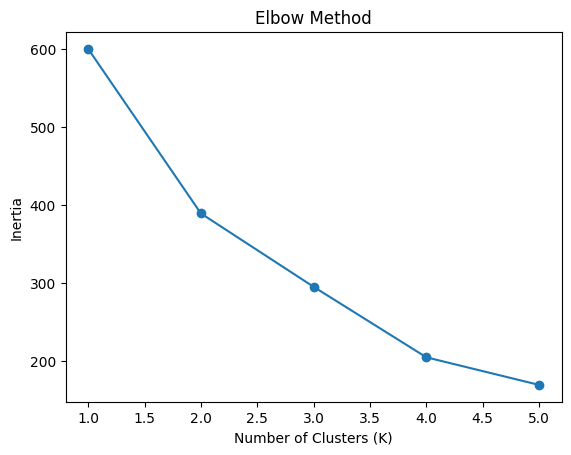

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,6):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,6), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Cell 5 - Train KMeans

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Segmentation Complete ✅")
display(df.head())

Segmentation Complete ✅


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


Cell 6 - Visualization

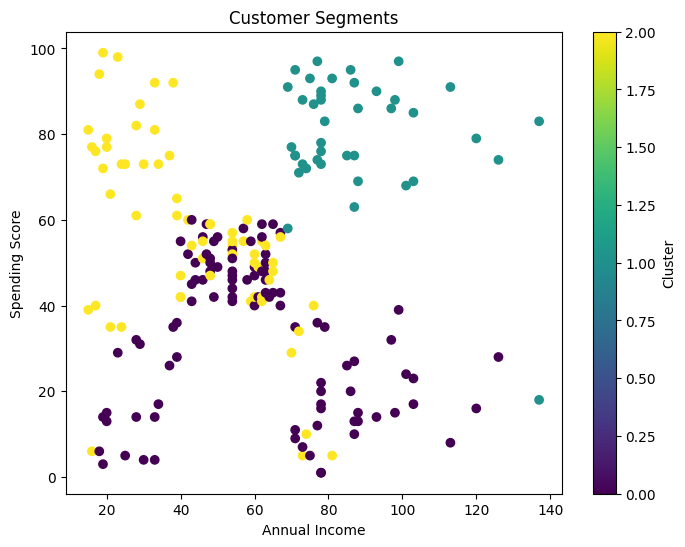

In [14]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.colorbar(scatter, label="Cluster")
plt.show()

Cell 7 - Cluster Analysis

In [15]:
# ✅ Cluster Analysis (numeric means only)
numeric_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
cluster_summary = df.groupby("Cluster")[numeric_cols].mean()

print("Cluster Means (Numeric):")
display(cluster_summary)

print("\nCustomers Per Cluster:")
print(df["Cluster"].value_counts())

print("\nGender Breakdown Per Cluster:")
display(pd.crosstab(df["Cluster"], df["Gender"], normalize="index"))

Cluster Means (Numeric):


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,50.406250,60.468750,33.343750
1,32.853659,87.341463,79.975610
2,25.142857,43.269841,56.507937



Customers Per Cluster:
Cluster
0    96
2    63
1    41
Name: count, dtype: int64

Gender Breakdown Per Cluster:


Gender,Female,Male
Cluster,,
0,0.552083,0.447917
1,0.536585,0.463415
2,0.587302,0.412698


Cell 8 - Save Results

In [16]:
df.to_csv("segmented_customers.csv", index=False)
print("CSV Saved ✅")

CSV Saved ✅


K-Means clustering grouped customers into distinct segments based on age, income, and spending behavior.

The elbow method helped validate the number of clusters used.

Observations:

- One cluster represents high-income high-spending customers, ideal targets for premium marketing.

- Another cluster shows moderate spending behavior, suitable for retention campaigns.

- A third cluster includes lower spending customers, where cost-efficient engagement strategies are appropriate.

Customer segmentation enables businesses to tailor marketing strategies, improve customer engagement, and allocate resources efficiently.

**COMPLETE Extra Credit Section**

# Extra Credit — AI Housing Demand Forecast (Forecasting)

This section builds a simple AI-powered housing demand forecasting tool.
Historical housing data is loaded from CSV, a Linear Regression model is trained,
and demand/prices are forecasted for the next 6 months.

Dataset Source:
Housing Price Dataset — Kaggle  
https://www.kaggle.com/datasets/muhammadbinimran/housing-price-prediction-data


Cell 1 - Load Data

In [17]:
import pandas as pd

df = pd.read_csv("housing_price_dataset.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (50000, 6)


,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065


Cell 2 - Prep Time Feature

In [18]:
import numpy as np

# Create synthetic time index (monthly steps)
df["Month_Index"] = np.arange(len(df))

# Choose target column (adjust if needed)
target = df.select_dtypes(include=np.number).columns[-2]

X = df[["Month_Index"]]
y = df[target]

print("Target used:", target)

Target used: Price


Cell 3 - Train Regression Model

In [19]:
model = LinearRegression()
model.fit(X, y)

print("Model trained ✅")

Model trained ✅


Cell 4 - Forecast Next 6 Months

In [20]:
future_months = np.arange(len(df), len(df)+6).reshape(-1,1)
predictions = model.predict(pd.DataFrame(future_months, columns=["Month_Index"]))

forecast_df = pd.DataFrame({
    "Month_Index": future_months.flatten(),
    "Forecast": predictions
})

display(forecast_df)

,Month_Index,Forecast
0,50000,224402.379627
1,50001,224402.362629
2,50002,224402.345632
3,50003,224402.328634
4,50004,224402.311637
5,50005,224402.294639


Cell 5 - Visualization

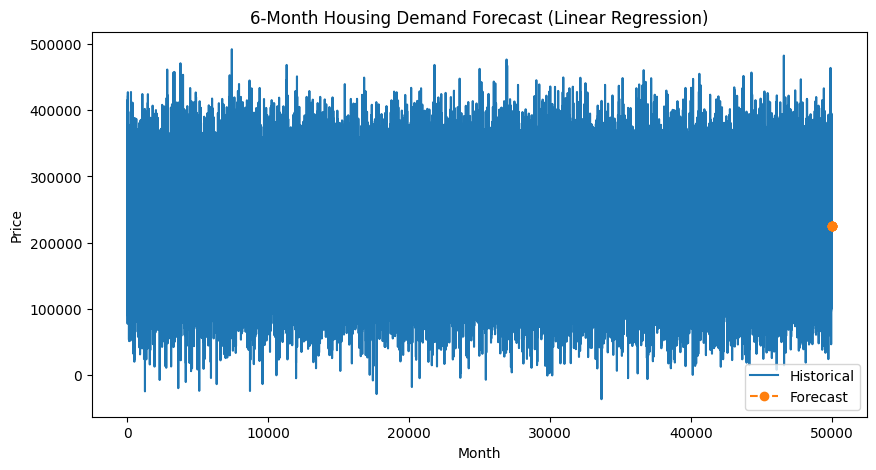

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df["Month_Index"], y, label="Historical")
plt.plot(forecast_df["Month_Index"],
         forecast_df["Forecast"],
         linestyle="--",
         marker="o",
         label="Forecast")

plt.xlabel("Month")
plt.ylabel(target)
plt.title("6-Month Housing Demand Forecast (Linear Regression)")
plt.legend()
plt.show()

### Interpretation
The model projects relatively stable demand over the next six months based on the historical trend.  
Because the model uses a simple linear regression with time index only, predictions reflect overall trend rather than seasonal or economic effects.

### Assumptions
- Dataset lacks explicit time information, so a monthly index was simulated.
- Linear trends were assumed for forecasting demand.

### Challenges
- Real housing markets are influenced by seasonality, interest rates, and economic factors.
- Linear Regression cannot capture complex nonlinear trends.

### Improvements
- Use larger time-series dataset
- Apply Random Forest or XGBoost
- Use ARIMA/LSTM for advanced forecasting
- Incorporate macroeconomic indicators

This simple model demonstrates how AI tools can support housing demand planning and decision-making.